2.3.1 Загрузка данных и первичный осмотр

In [236]:
# 1. Импортирование необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas import Series, Index, DataFrame

In [ ]:
# 2. Загрузка учебного датасета
file: str = 'S02-hw-dataset.csv'
data: DataFrame = pd.read_csv(file, sep=',')

In [ ]:
# 3. - Вывод первых строк датасета
data.head(n=10)

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296
5,6,120.0,FR,-1,785
6,7,46.0,RU,0,0
7,8,28.0,CN,2,456
8,9,39.0,US,4,980
9,10,24.0,RU,7,511


In [ ]:
# - Вывод информации о столбцах и типах
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [ ]:
# - Вывод базовых описательных характеристик
data.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


2.3.2. Пропуски, дубликаты и базовый контроль качества

In [ ]:
# 1. Доля пропусков в каждом столбце. Первый способ
data.isna().mean()

user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64

In [57]:
# Второй способ
count_data: Series = data.count()
count_rows, count_columns = data.shape
for key in count_data.keys():
    ratio: int = (count_rows - count_data[key]) / count_rows
    print(f'{key}: {ratio:.5f}')

user_id: 0.00000
age: 0.04878
country: 0.00000
purchases: 0.00000
revenue: 0.00000


In [61]:
# 2. Проверка на наличие полностью дублирующих строк
print(sum(data.duplicated()))
print('---------')
print(data.duplicated())

1
---------
0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40     True
dtype: bool


In [72]:
# 3. "Подозрительные" случаи. age
print('correct age-based data')
def correct_age(age: int) -> bool:
    return 0 < age < 100

age_correct = data['age'].apply(correct_age)
filtred_data: DataFrame = data[age_correct]
print(filtred_data.head(5))

print('\nincorrect rows based on age')
def incorrect_age(age):
    return not(0 < age < 100)

age_incorrect = data['age'].apply(incorrect_age)
incorrect_rows: DataFrame = data[age_incorrect]
print(incorrect_rows)

coorect age-based data
   user_id   age country  purchases  revenue
0        1  25.0      FR          7      749
1        2  24.0      RU          5     1115
2        3  52.0      FR          7      399
3        4  31.0      RU          6      654
6        7  46.0      RU          0        0

incorrect rows based on age
    user_id    age country  purchases  revenue
4         5    NaN      DE          6     1296
5         6  120.0      FR         -1      785
12       13    NaN      US          9      630


In [86]:
# purchases
print('correct purchases-based data')
def correct_purchases(value: int) -> bool:
    return not(value < 0)

purchases_correct = data['purchases'].apply(correct_purchases)
filtred_data = data[purchases_correct]
print(filtred_data.head(5))

print('\nincorrect purchases-based data')
def incorrect_purchases(value: int) -> bool:
    return value < 0

purchases_incorrect = data['purchases'].apply(incorrect_purchases)
incorrect_rows = data[purchases_incorrect]
print(incorrect_rows)

correct purchases-based data
   user_id   age country  purchases  revenue
0        1  25.0      FR          7      749
1        2  24.0      RU          5     1115
2        3  52.0      FR          7      399
3        4  31.0      RU          6      654
4        5   NaN      DE          6     1296

incorrect purchases-based data
   user_id    age country  purchases  revenue
5        6  120.0      FR         -1      785


In [88]:
# revenue
print('correct revenue-based data')
def correct_revenue(row: Series) -> bool:
    if row['revenue'] < 0:
        return False
    if (row['purchases'] > 0) and (row['revenue'] <= 0):
        return False
    return True

revenue_correct = data.apply(correct_revenue, axis=1)
filtred_data = data[revenue_correct]
print(filtred_data.head(5))


print('\nincorrect revenue-based data')
def incorrect_revenue(row: Series) -> bool:
    if row['revenue'] < 0:
        return True
    if (row['purchases'] > 0) and (row['revenue'] <= 0):
        return True
    return False

revenue_incorrect = data.apply(incorrect_revenue, axis=1)
incorrect_rows = data[revenue_incorrect]
print(incorrect_rows)

correct revenue-based data
   user_id   age country  purchases  revenue
0        1  25.0      FR          7      749
1        2  24.0      RU          5     1115
2        3  52.0      FR          7      399
3        4  31.0      RU          6      654
4        5   NaN      DE          6     1296

incorrect revenue-based data
    user_id   age country  purchases  revenue
10       11  24.0      US          4        0


In [91]:
# user_id
print('duplicates rows')
duplicates_rows = data.user_id.duplicated()
print(data[duplicates_rows])


duplicates rows
    user_id   age country  purchases  revenue
40       10  24.0      RU          7      511


В представленном датасете были обнаружены следующие проблемы:

Полнота: не все поля были заполнены. Например: age в 4 и 12 строке были пропущены.

Целостность: при положительных продажах сумма выручки оказалось равной нулю, что противоречит здравому смыслу.

Уникальность: на 40 строке обнаружено дублирование строки.

Валидность: были обнаружены поля лежащие вне диапазона здравого смысла.
- Возраст: на 5 строке возраст равен 120 (либо французский долгожитель, либо невалидные данные)
- Количество продаж: на 5 строке продажи равны -1. Мы получили товар и оплату за него)))

2.3.3 Базовый EDA: группировки, агрегаты и частоты

In [95]:
# 1. Частота для категориальной переменной
data.country.value_counts()

country
RU    13
FR    12
US     8
DE     6
CN     2
Name: count, dtype: int64

In [129]:
group = data.groupby('country')

result = group.agg({
    'age': 'mean',
    'purchases': ['count', 'sum', 'mean', 'max'],
    'revenue': ['sum', 'mean', 'max']
})

print(result)

               age purchases                   revenue                   
              mean     count sum      mean max     sum         mean   max
country                                                                  
CN       24.000000         2   9  4.500000   7    2108  1054.000000  1652
DE       34.600000         6  39  6.500000  11    8673  1445.500000  2475
FR       46.250000        12  51  4.250000   7    8111   675.916667  1608
RU       30.076923        13  62  4.769231   8   10271   790.076923  2086
US       36.714286         8  37  4.625000   9    4459   557.375000   980


В Китае очень мало продаж, мало продали и мало заработали. В Китае самые молодые покупателию. А в Франции самые старые.
Самая прибыльная страна оказалась Россия, больше всего продаж и сумма дохода. При этом максимальная доходность зафиксирована в Германии.
При средних показателях продажи, США оказалась ниже среднего по доходности, близкой к Китаю, что очень странно.

2.4 Визуализация данных в Matplotlib

In [ ]:
duplicates_data = data.duplicated()
first_filtred = data[~duplicates_data]
# print(first_filtred.shape)
age_correct = first_filtred['age'].apply(correct_age)
second_filtred = first_filtred[age_correct]
# print(second_filtred.shape)
purchases_correct = second_filtred['purchases'].apply(correct_purchases)
third_filtred = second_filtred[purchases_correct]
# print(third_filtred.shape)
revenue_correct = third_filtred.apply(correct_revenue, axis=1)
fourth_filtred = third_filtred[revenue_correct]
# print(fourth_filtred.shape)
clean_data = fourth_filtred


    user_id   age country  purchases  revenue
0         1  25.0      FR          7      749
1         2  24.0      RU          5     1115
2         3  52.0      FR          7      399
3         4  31.0      RU          6      654
6         7  46.0      RU          0        0
7         8  28.0      CN          2      456
8         9  39.0      US          4      980
9        10  24.0      RU          7      511
11       12  20.0      CN          7     1652
13       14  36.0      DE          9     2358
14       15  57.0      FR          7      693
15       16  22.0      FR          3      183
16       17  32.0      FR          6     1608
17       18  24.0      RU          0        0
18       19  47.0      RU          3      432
19       20  31.0      RU          2      442
20       21   5.0      RU          8     1488
21       22  33.0      FR          6      546
22       23  42.0      US          4      904
23       24  32.0      DE         11     2475
24       25  21.0      RU         

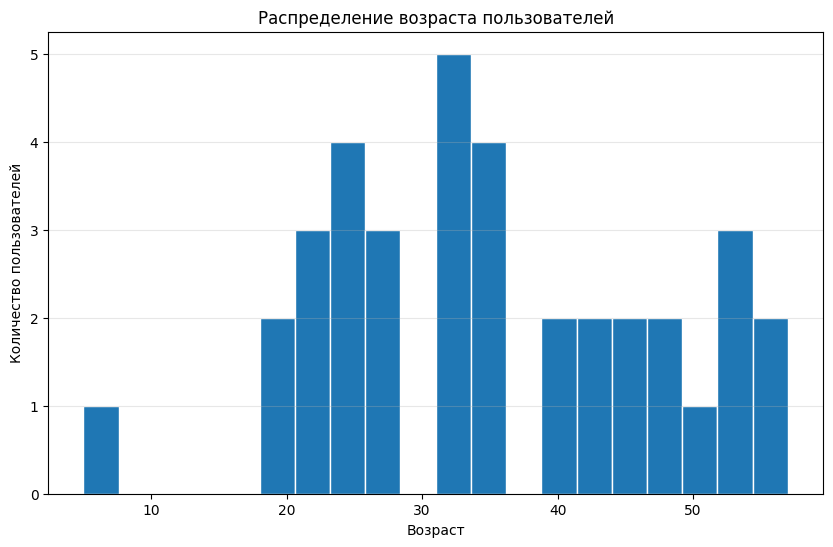

In [258]:
# Гистограмма возраста
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(clean_data['age'], bins=20, edgecolor='white', alpha=1)
ax.set_xlabel('Возраст')
ax.set_ylabel('Количество пользователей')
ax.set_title('Распределение возраста пользователей')
ax.grid(axis='y', alpha=0.3)
plt.savefig('figures/fig_hist.png', 
            dpi=300, bbox_inches='tight')
plt.show()
# Распределение возраста близко к нормальному с пиком в районе 25-35 лет

C:\Users\Ezh7k\AppData\Local\Temp\ipykernel_6912\1786256851.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(revenue_data, labels=countries)


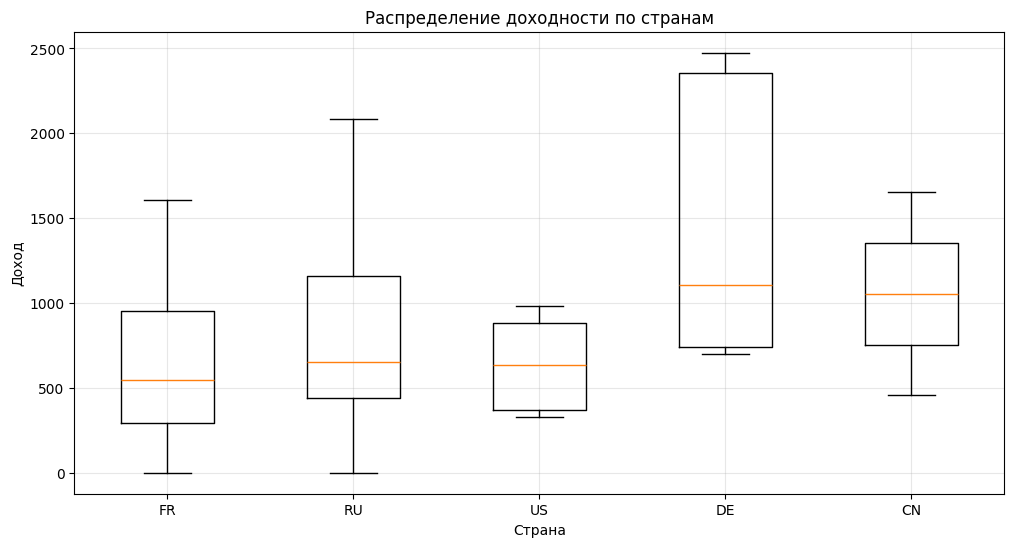

In [259]:
# boxplot revenue по странам
fig, ax = plt.subplots(figsize=(12, 6))
countries = ['FR', 'RU', 'US', 'DE', 'CN']
revenue_data = [clean_data[clean_data['country'] == country]['revenue'] for country in countries]

ax.boxplot(revenue_data, labels=countries)
ax.set_xlabel('Страна')
ax.set_ylabel('Доход')
ax.set_title('Распределение доходности по странам')
ax.grid(alpha=0.3)
plt.savefig('figures/fig_boxplot.png', 
            dpi=300, bbox_inches='tight')
plt.show()
# Германия показывает наибольшую медианную доходность, 
# в то время как Франция (FR) имеет самый широкий разброс значений

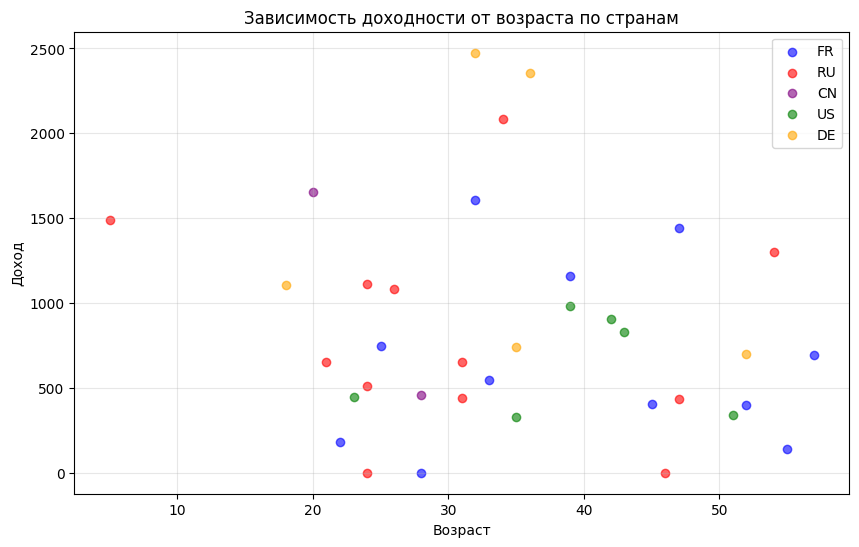

In [260]:
# Scatter plot: возраст vs доходность
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'FR': 'blue', 'RU': 'red', 'US': 'green', 'DE': 'orange', 'CN': 'purple'}

for country in clean_data['country'].unique():
    country_data = clean_data[clean_data['country'] == country]
    plt.scatter(country_data['age'], country_data['revenue'], 
               c=colors[country], label=country, alpha=0.6)

ax.set_xlabel('Возраст')
ax.set_ylabel('Доход')
ax.set_title('Зависимость доходности от возраста по странам')
ax.legend()
ax.grid(alpha=0.3)
plt.savefig('figures/fig_scatter_plot.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Четкой линейной зависимости между возрастом и доходностью не наблюдается,
# но видно, что пользователи из Германии (оранжевые) чаще показывают высокую доходность